Rellenar datos faltantes con el body o title? Rellenar ciudades y adress con latitud y longitud? dividir por barrio? como usamos latitud y longitud para todo eso? nos interesa la fecha? hasta lo que tengo de conocimeinto lo que mas influye en el precio es la zona, el metro cuadrado en puntac arretas es mas elevado que en pocitos, despues los cuarts, baños (como los completo)?
Barrio separar latitud y longitud y usar distancia y mediana, usar zip para barrios.
Hacer correlacion y si hay muchas que estan altamente relacionadas usar PCA para achicar variables que usamos.

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

In [267]:
df = pd.read_csv('Resources/Tema_9.csv',encoding='latin1', delimiter=';')

In [272]:
print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n Primeras 5 filas:")
df.head(10)




Dimensiones del dataset: 10000 filas x 22 columnas

 Primeras 5 filas:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401
5,5667891676,housing/rent/apartment,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,USD,No,Thumbnail,...,"$2,475",Monthly,130,350 West 50th St,Manhattan,NY,40.7629,-73.9885,Listanza,1577289784
6,5668627426,housing/rent/apartment,Studio apartment 2432 Penmar Ave,"This unit is located at 2432 Penmar Ave, Venic...",NaN,NaN,0.0,USD,No,Thumbnail,...,"$1,800",Monthly,132,2432 Penmar Avenue,Venice,CA,33.9932,-118.4609,RentLingo,1577359461
7,5668626687,housing/rent/apartment,"Studio apartment Oak St NW, 16th St NW, Washin...","This unit is located at Oak St NW, 16th St NW,...",NaN,NaN,0.0,USD,No,Thumbnail,...,$840,Monthly,136,NaN,Washington,DC,38.9328,-77.0297,RentLingo,1577359393
8,5668610290,housing/rent/apartment,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",Refrigerator,1.0,0.0,USD,No,Thumbnail,...,"$1,495",Monthly,138,333 Hyde St,San Francisco,CA,37.7599,-122.4379,RentLingo,1577358313
9,5668627023,housing/rent/apartment,"Studio apartment A St SE, 19th St SE, Washington","This unit is located at A St SE, 19th St SE, W...",NaN,NaN,0.0,USD,No,Thumbnail,...,$890,Monthly,141,NaN,Washington,DC,38.9118,-77.0132,RentLingo,1577359424


Para el precio vamos a usar price en vez de price_display.

In [273]:
print("\n Últimas 5 filas:")
df.tail()


 Últimas 5 filas:


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
9995,5630240092,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,This unit is located at 5407 Abbott Place - Ab...,NaN,4.0,5.0,USD,No,Thumbnail,...,"$6,000",Monthly,6300,5407 Abbott Place Abbott,Edina,MN,44.9000,-93.3233,RentLingo,1575112975
9996,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,USD,No,Thumbnail,...,"$25,000",Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1577360419
9997,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,USD,No,Thumbnail,...,"$11,000",Monthly,11318,9908 Bentcross Dr,Potomac,MD,39.0287,-77.2409,RentLingo,1577360560
9998,5668662559,housing/rent/apartment,One BR in New York NY 10069,"Monthly Rent$4,605 -to $4,790AmenitiesThe Aldy...","Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,USD,No,Thumbnail,...,"$4,790",Monthly,40000,NaN,New York,NY,40.7716,-73.9876,Listanza,1577362186
9999,5509132540,housing/rent/apartment,Beautiful Lawrenceville Apartment for rent,"Square footage: 880 sq. feet, unit number: 150...","Gym,Patio/Deck",1.0,1.0,USD,No,No,...,"$1,009",Monthly,880,NaN,Lawrenceville,GA,34.0072,-84.0034,RentDigs.com,1577362141


In [274]:
print("\nInformación de columnas:")
print(df.info())

print("\nTipos de datos por columna:")
print(df.dtypes)




Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-n

In [275]:
print("\nEstadísticas descriptivas (variables númericas):")
df.describe()


Estadísticas descriptivas (variables númericas):


,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [276]:
print("\nEstadísticas descriptivas (variables categóricas):")
df.describe(include=['object'])


Estadísticas descriptivas (variables categóricas):


,category,title,body,amenities,currency,fee,has_photo,pets_allowed,price_display,price_type,address,cityname,state,source
count,10000,10000,10000,6451,10000,10000,10000,5837,10000,10000,6673,9923,9923,10000
unique,3,9350,9961,2254,1,1,3,3,1726,3,6658,1574,51,12
top,housing/rent/apartment,Apartment in great location,"When searching for a pet-friendly One-, Two- a...",Parking,USD,No,Thumbnail,"Cats,Dogs","$1,350",Monthly,908 8th SW St,Austin,TX,RentLingo
freq,9996,40,6,229,10000,10000,8907,5228,86,9998,3,523,1737,6912


              Cantidad  Porcentaje
pets_allowed      4163       41.63
amenities         3549       35.49
address           3327       33.27
cityname            77        0.77
state               77        0.77
bathrooms           34        0.34
latitude            10        0.10
longitude           10        0.10
bedrooms             7        0.07


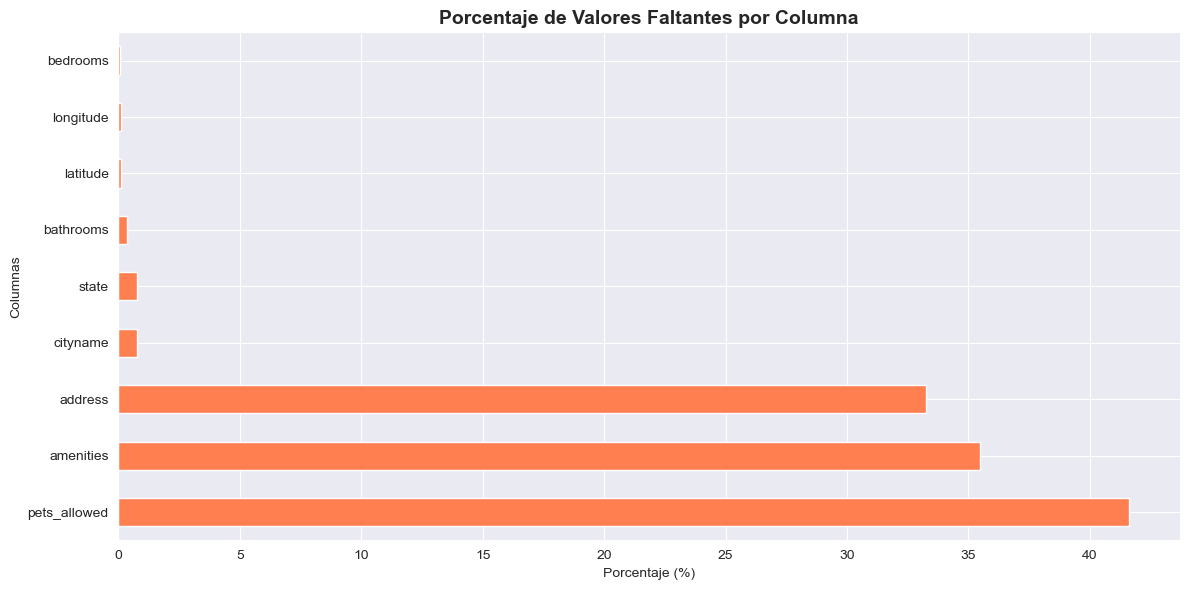

In [277]:
missing_data = pd.DataFrame({
    'Cantidad': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Cantidad'] > 0].sort_values('Cantidad', ascending=False)
print(missing_data)
if not missing_data.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_data['Porcentaje'].plot(kind='barh', color='coral', ax=ax)
    ax.set_title('Porcentaje de Valores Faltantes por Columna', fontsize=14, fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Columnas')
    plt.tight_layout()
    plt.show()

Dado que son 10000 valores decidimos eliminar las filas que tengan missing values en alguna de las siguientes columnas: bathroom, latitud, longitud, bedrooms. Son pocos registros que no van a aportar y quizas imputarle valores nos perjudique mas de lo que nos puede beneficiar.

In [278]:
columnas= ['bathrooms', 'latitude', 'longitude', 'bedrooms']

# Verificar cuántas filas se van a eliminar
print(f"Registros antes: {len(df)}")
print(f"Registros con nulos en columnas críticas: {df[columnas].isnull().any(axis=1).sum()}")

# Eliminar filas
df = df.dropna(subset=columnas)

print(f"Registros después: {len(df)}")

Registros antes: 10000
Registros con nulos en columnas críticas: 50
Registros después: 9950


In [279]:
print(f"Valores duplicados: {df.duplicated().sum()}")
print(f"Valores unicos por columna: \n{df.nunique().sort_values(ascending=False)}")


Valores duplicados: 0
Valores unicos por columna: 
id               9950
body             9911
title            9301
address          6631
time             6299
latitude         2388
longitude        2386
amenities        2249
square_feet      1725
price_display    1724
price            1723
cityname         1572
state              51
bathrooms          14
source             12
bedrooms           10
category            3
pets_allowed        3
has_photo           3
price_type          2
fee                 1
currency            1
dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"   • {col}: {unique_count:,}")

    # Mostrar top 5 si tiene sentido
    if 2 < unique_count < 500:
        print(f"      Top 3: {df[col].value_counts().head(3).to_dict()}")


Currency y fee se pueden eliminar, el currency sabemos que es en USD y el fee es el mismo para todos entonces no va a afectar a las predicciones

In [ ]:
df_pets_vacios = df[df['pets_allowed'].isnull()]

# Opción 1: Usar non-capturing group (?:...)
patron = r'\b(?:pet|pets|dog|dogs|cat|cats|mascota|mascotas|perro|gato|animal|animals)\b'

# Opción 2: Sin paréntesis (más simple)
patron = r'\bpet\b|\bpets\b|\bdog\b|\bdogs\b|\bcat\b|\bcats\b|\banimal\b|\banimals\b'

# Encontrar descripciones que mencionan mascotas
menciona_pets = df_pets_vacios[
    df_pets_vacios['body'].str.contains(patron, case=False, na=False, regex=True)
]

# Ver los resultados
print(f"Total con pets_allowed nulo: {len(df_pets_vacios)}")
print(f"De esos, mencionan mascotas: {len(menciona_pets)}")
menciona_pets['body']
solo_dog = menciona_pets[
    menciona_pets['body'].str.contains(r'\bdog\b|\bdogs\b', case=False, na=False, regex=True)
]

solo_cat = menciona_pets[
    menciona_pets['body'].str.contains(r'\bcat\b|\bcats\b', case=False, na=False, regex=True)
]

solo_pets = menciona_pets[
    menciona_pets['body'].str.contains(r'\bpet\b|\bpets\b', case=False, na=False, regex=True)
]

# Ver resultados
print(f"Mencionan 'dog/dogs': {len(solo_dog)}")
print(f"Mencionan 'cat/cats': {len(solo_cat)}")
print(f"Mencionan 'pet/pets': {len(solo_pets)}")
#Con esta info completaremos algunos de los missing values, los que no se completen con estos valores se le imputara el valor Unknown. Se les imputara el valor 0 a los que sean unknown y 1 a los que permitan algun tipo de mascota.

In [ ]:
# ver los valores que mas aparecen en los ammenities y buscarlos en el body para completar valores faltantes


In [ ]:
print("\n Estadísticas del Precio:")
print(f"   • Media: ${df['price'].mean():,.2f}")
print(f"   • Mediana: ${df['price'].median():,.2f}")
print(f"   • Desv. Estándar: ${df['price'].std():,.2f}")
print(f"   • Mínimo: ${df['price'].min():,.2f}")
print(f"   • Máximo: ${df['price'].max():,.2f}")
print(f"   • Rango: ${df['price'].max() - df['price'].min():,.2f}")
print(f"   • CV (Coef. Variación): {(df['price'].std() / df['price'].mean()) * 100:.2f}%")

In [ ]:
#Deteccion de outliers
#Metodo IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = df[(df['price'] < lower_iqr) | (df['price'] > upper_iqr)]
print(f"      • Límite inferior: ${lower_iqr:,.2f}")
print(f"      • Límite superior: ${upper_iqr:,.2f}")
print(f"      • Outliers detectados: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")

In [ ]:
#Metodo de Z-score
z_scores = np.abs(stats.zscore(df['price']))
outliers_zscore = df[z_scores > 3]
print(f"      • Outliers detectados: {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")


In [ ]:
#Metodo de percentiles
outliers_percentile = df[(df['price'] < df['price'].quantile(0.01)) |
                         (df['price'] > df['price'].quantile(0.99))]
print(f"      • Outliers detectados: {len(outliers_percentile)} ({len(outliers_percentile)/len(df)*100:.2f}%)")

In [ ]:
# Top y bottom precios
print("\n TOP 10 PRECIOS MÁS ALTOS:")
print(df.nlargest(10, 'price')[['price', 'bedrooms', 'bathrooms', 'square_feet', 'cityname', 'state']])

print("\n TOP 10 PRECIOS MÁS BAJOS:")
print(df.nsmallest(10, 'price')[['price', 'bedrooms', 'bathrooms', 'square_feet', 'cityname', 'state']])


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Completo de Distribución del Precio', fontsize=16, fontweight='bold')

# 1. Histograma
axes[0, 0].hist(df['price'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["price"].mean():.0f}')
axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["price"].median():.0f}')
axes[0, 0].set_title('Distribución de Precios')
axes[0, 0].set_xlabel('Precio ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# 2. Boxplot
bp = axes[0, 1].boxplot(df['price'].dropna(), vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].set_title('Boxplot de Precios')
axes[0, 1].set_ylabel('Precio ($)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot
stats.probplot(df['price'].dropna(), dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot (Test de Normalidad)')

# 4. Log transformation
axes[1, 0].hist(np.log1p(df['price']), bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Distribución Log-Transformada')
axes[1, 0].set_xlabel('Log(Precio + 1)')
axes[1, 0].set_ylabel('Frecuencia')

# 5. Violin plot por rango de precios
df['price_range'] = pd.cut(df['price'], bins=[0, 1000, 1500, 2000, df['price'].max()],
                            labels=['<$1K', '$1-1.5K', '$1.5-2K', '>$2K'])
sns.violinplot(data=df, x='price_range', y='price', ax=axes[1, 1])
axes[1, 1].set_title('Violin Plot por Rango de Precio')
axes[1, 1].set_xlabel('Rango de Precio')
axes[1, 1].set_ylabel('Precio ($)')

# 6. Cumulative distribution
axes[1, 2].hist(df['price'], bins=100, cumulative=True, density=True,
                histtype='step', linewidth=2, color='purple')
axes[1, 2].set_title('Distribución Acumulativa')
axes[1, 2].set_xlabel('Precio ($)')
axes[1, 2].set_ylabel('Probabilidad Acumulada')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
import re
patron_si = r'''
    \b(?:
        (?:pet|pets|dog|dogs|cat|cats|animals?)\s*(?:allowed|welcome|friendly|ok|permitted|accepted|negotiable)|
        (?:dog|cat|pet)\s*friendly|
        accepts?\s*(?:pet|dog|cat)s?|
        (?:pet|dog|cat)s?\s*(?:are\s*)?(?:welcome|ok|allowed)|
        with\s*(?:pet|dog|cat)s?
    )\b
'''

# Patrones para "NO permite mascotas"
patron_no = r'''
    \b(?:
        no\s*(?:pet|dog|cat|animal)s?|
        (?:pet|dog|cat|animal)s?\s*(?:not\s*allowed|prohibited|restricted|banned)|
        (?:pet|dog|cat|animal)\s*free|
        without\s*(?:pet|dog|cat)s?|
        (?:pet|dog|cat)s?\s*not\s*permitted
    )\b
'''

# Compilar patrones (case-insensitive, verbose para permitir comentarios)
regex_si = re.compile(patron_si, re.IGNORECASE | re.VERBOSE)
regex_no = re.compile(patron_no, re.IGNORECASE | re.VERBOSE)

def clasificar_pets_desde_body(body):
    """
    Clasifica la política de mascotas basándose en el texto de body.

    Returns:
        'Yes': Si permite mascotas explícitamente
        'No': Si NO permite mascotas explícitamente
        'Unknown': Si no se menciona o no es claro
    """
    if pd.isna(body) or body == '':
        return 'Unknown'

    body_lower = str(body).lower()

    # Buscar primero patrones negativos (más específicos)
    if regex_no.search(body_lower):
        return 'No'

    # Luego buscar patrones positivos
    if regex_si.search(body_lower):
        return 'Yes'

    # No menciona o no es claro
    return 'Unknown'

# Aplicar clasificación solo a valores nulos
print(f"\n   🔍 Analizando {df['pets_allowed'].isnull().sum()} registros con 'body' para inferir política de mascotas...")

nulls_mask = df['pets_allowed'].isnull()
df.loc[nulls_mask, 'pets_allowed'] = df.loc[nulls_mask, 'body'].apply(clasificar_pets_desde_body)

In [ ]:
# Normalizar valores existentes primero
df['pets_allowed'] = df['pets_allowed'].fillna('Unknown').astype(str).str.strip().str.title()

# Mapping para conversión numérica
# 1 = Permite mascotas (Cats, Dogs, Yes, o combinaciones)
# 0 = No permite o Unknown

def pets_to_numeric(value):
    """
    Convierte pets_allowed a numérico:
    1 = Permite mascotas
    0 = No permite o desconocido
    """
    if pd.isna(value):
        return 0

    value_str = str(value).lower()

    # Considera como "permite mascotas" si menciona cats, dogs o yes
    if any(pet in value_str for pet in ['cat', 'dog', 'yes']):
        return 1
    else:
        return 0

# Crear columnas auxiliares ANTES de sobrescribir (para análisis posterior)
df['allows_cats'] = df['pets_allowed'].str.contains('Cat', case=False, na=False).astype(int)
df['allows_dogs'] = df['pets_allowed'].str.contains('Dog', case=False, na=False).astype(int)

# SOBRESCRIBIR la columna original con valores numéricos
df['pets_allowed'] = df['pets_allowed'].apply(pets_to_numeric)


Para completar ciudad y estados vamos a usar la herramienta geopy para reverse geocoding con latitud y longitud

In [ ]:
city_missing = df['cityname'].isnull().sum()
state_missing = df['state'].isnull().sum()

if city_missing > 0 or state_missing > 0:
    print(f"   Registros a procesar: {max(city_missing, state_missing)}")

    try:
        from geopy.geocoders import Nominatim
        from geopy.exc import GeocoderTimedOut, GeocoderServiceError
        import time
    except ImportError:
        print("   ERROR: geopy no instalado. Imputando con moda...")
        if city_missing > 0:
            mode_city = df['cityname'].mode()[0] if not df['cityname'].mode().empty else 'Unknown'
            df['cityname'].fillna(mode_city, inplace=True)
        if state_missing > 0:
            mode_state = df['state'].mode()[0] if not df['state'].mode().empty else 'Unknown'
            df['state'].fillna(mode_state, inplace=True)
    else:
        geolocator = Nominatim(user_agent="apartment_rental_prediction_2025")

        def reverse_geocode(lat, lon, max_retries=3):
            for attempt in range(max_retries):
                try:
                    time.sleep(1.1)
                    location = geolocator.reverse(f"{lat}, {lon}", language='en', timeout=10)

                    if location and location.raw.get('address'):
                        address = location.raw['address']
                        city = (address.get('city') or address.get('town') or
                               address.get('village') or address.get('municipality') or
                               address.get('county'))
                        state = address.get('state')
                        return {'city': city, 'state': state}
                    return None
                except (GeocoderTimedOut, GeocoderServiceError):
                    if attempt < max_retries - 1:
                        time.sleep(2)
                        continue
                    return None
                except:
                    return None
            return None

        needs_geocoding = (df['cityname'].isnull() | df['state'].isnull())
        total_to_process = needs_geocoding.sum()

        geocoded = 0
        failed = 0

        for idx in df[needs_geocoding].index:
            row = df.loc[idx]
            if pd.notna(row['latitude']) and pd.notna(row['longitude']):
                result = reverse_geocode(row['latitude'], row['longitude'])

                if result:
                    if result['city'] and pd.isna(df.at[idx, 'cityname']):
                        df.at[idx, 'cityname'] = result['city']
                    if result['state'] and pd.isna(df.at[idx, 'state']):
                        df.at[idx, 'state'] = result['state']
                    geocoded += 1
                else:
                    failed += 1

                if (geocoded + failed) % 20 == 0:
                    print(f"   Progreso: {geocoded + failed}/{total_to_process}")

        print(f"   Geocoding: {geocoded} exitosos, {failed} fallidos")

        if df['cityname'].isnull().sum() > 0 or df['state'].isnull().sum() > 0:
            if df['cityname'].isnull().sum() > 0:
                mode_city = df['cityname'].mode()[0] if not df['cityname'].mode().empty else 'Unknown'
                df['cityname'].fillna(mode_city, inplace=True)
            if df['state'].isnull().sum() > 0:
                mode_state = df['state'].mode()[0] if not df['state'].mode().empty else 'Unknown'
                df['state'].fillna(mode_state, inplace=True)
else:
    print(f"   No hay valores faltantes")

In [ ]:
df_adress_vacio = df[df['address'].isnull()]
df_adress_vacio['body']

In [264]:
import requests
import time


API_KEY = 'pk.a459e637514204ec031df5d30bd009c4'

mask_need_geocoding = (
    df['address'].isna() &
    df['latitude'].notna() &
    df['longitude'].notna()
)

registros_geocodificar = mask_need_geocoding.sum()
print(f"\nRegistros a geocodificar: {registros_geocodificar}")

if registros_geocodificar > 0 and API_KEY != 'TU_API_KEY_AQUI':
    print("\nIniciando geocodificación inversa con LocationIQ...")
    print("(Mucho más rápido que Nominatim)")

    # Contador de éxitos
    geocoded_count = 0
    error_count = 0

    # Procesar solo los registros que necesitan geocodificación
    indices_to_process = df[mask_need_geocoding].index
    total_to_process = len(indices_to_process)

    start_time = time.time()

    for i, idx in enumerate(indices_to_process, 1):
        try:
            lat = df.loc[idx, 'latitude']
            lon = df.loc[idx, 'longitude']

            # Geocodificación inversa con LocationIQ
            url = "https://us1.locationiq.com/v1/reverse.php"
            params = {
                'key': API_KEY,
                'lat': lat,
                'lon': lon,
                'format': 'json'
            }

            response = requests.get(url, params=params, timeout=10)

            if response.status_code == 200:
                data = response.json()
                address = data.get('display_name')

                if address:
                    df.loc[idx, 'address'] = address
                    geocoded_count += 1
            else:
                error_count += 1

            # Mostrar progreso cada 10 registros
            if i % 10 == 0 or i == total_to_process:
                elapsed = time.time() - start_time
                rate = i / elapsed if elapsed > 0 else 0
                remaining = (total_to_process - i) / rate if rate > 0 else 0
                print(f"  Progreso: {i}/{total_to_process} | "
                      f"Éxitos: {geocoded_count} | Errores: {error_count} | "
                      f"Velocidad: {rate:.1f} req/s | Restante: ~{remaining:.0f}s")

            # Rate limiting: pequeña pausa (LocationIQ es más permisivo)
            time.sleep(0.2)

        except Exception as e:
            error_count += 1
            if error_count <= 5:  # Mostrar solo los primeros 5 errores
                print(f"  Error en índice {idx}: {e}")
            continue

    elapsed_total = time.time() - start_time

    print(f"\n✓ Geocodificación completada en {elapsed_total:.1f} segundos!")
    print(f"  Éxitos: {geocoded_count}")
    print(f"  Errores: {error_count}")
    print(f"  Velocidad promedio: {total_to_process/elapsed_total:.1f} registros/segundo")

elif API_KEY == 'pk.a459e637514204ec031df5d30bd009c4':
    print("\n⚠️  NECESITAS CONFIGURAR TU API KEY DE LOCATIONIQ")
    print("\nPasos:")
    print("1. Ve a: https://locationiq.com/register")
    print("2. Regístrate gratis (solo email y contraseña)")
    print("3. En tu dashboard, copia tu 'Access Token'")
    print("4. Pégalo en la variable API_KEY arriba")
    print("\n📊 Plan gratuito: 5,000 requests/día")

else:
    print("\n✓ No hay registros que necesiten geocodificación.")

# ============================================================================
# RESUMEN FINAL
# ============================================================================
print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)
print(f"Total registros: {len(df)}")
print(f"Address completados: {df['address'].notna().sum()}")
print(f"Address vacíos: {df['address'].isna().sum()}")
print(f"Porcentaje completado: {(df['address'].notna().sum() / len(df) * 100):.2f}%")

# Mostrar algunos ejemplos geocodificados
if geocoded_count > 0:
    print("\n" + "="*70)
    print("EJEMPLOS DE DIRECCIONES GEOCODIFICADAS:")
    print("="*70)
    geocoded_sample = df[mask_need_geocoding & df['address'].notna()].head(3)
    for idx, row in geocoded_sample.iterrows():
        print(f"\nLat: {row['latitude']}, Lon: {row['longitude']}")
        print(f"Address: {row['address'][:80]}...")

# Guardar resultado final
df.to_csv('rental_data_final.csv', index=False)
print("\n✓ Archivo guardado como 'rental_data_final.csv'")


Registros a geocodificar: 1737

Iniciando geocodificación inversa con LocationIQ...
(Mucho más rápido que Nominatim)
  Progreso: 10/1737 | Éxitos: 10 | Errores: 0 | Velocidad: 1.3 req/s | Restante: ~1342s
  Progreso: 20/1737 | Éxitos: 20 | Errores: 0 | Velocidad: 1.3 req/s | Restante: ~1286s
  Progreso: 30/1737 | Éxitos: 30 | Errores: 0 | Velocidad: 1.4 req/s | Restante: ~1253s
  Progreso: 40/1737 | Éxitos: 40 | Errores: 0 | Velocidad: 1.4 req/s | Restante: ~1199s
  Progreso: 50/1737 | Éxitos: 50 | Errores: 0 | Velocidad: 1.5 req/s | Restante: ~1141s
  Progreso: 60/1737 | Éxitos: 60 | Errores: 0 | Velocidad: 1.5 req/s | Restante: ~1119s
  Progreso: 70/1737 | Éxitos: 60 | Errores: 10 | Velocidad: 1.5 req/s | Restante: ~1104s
  Progreso: 80/1737 | Éxitos: 60 | Errores: 20 | Velocidad: 1.5 req/s | Restante: ~1100s
  Progreso: 90/1737 | Éxitos: 68 | Errores: 22 | Velocidad: 1.5 req/s | Restante: ~1098s
  Progreso: 100/1737 | Éxitos: 78 | Errores: 22 | Velocidad: 1.5 req/s | Restante: ~110

KeyboardInterrupt: 